# Ensemble Learning — Spaceship Titanic


In [20]:
# 1) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, StackingClassifier, GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
# optional libraries (install if needed)
# %pip install lightgbm xgboost catboost kagglehub
import xgboost as xgb

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


## Tải data

In [2]:
train_set = pd.read_csv('spaceship-titanic/train.csv')
test_set = pd.read_csv('spaceship-titanic/test.csv')
display(train_set.head())
display(test_set.head())


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


## EDA

- Check shape, kiểu dữ liệu, mô tả, xem thông tin về biến phân loại, biến số và biến bool
- Check missing values và outliers
- Xem mối tương quan giữa các biến số


In [3]:
print('Train shape:', train_set.shape)
print('Test shape:', test_set.shape)


Train shape: (8693, 14)
Test shape: (4277, 13)


In [4]:
display(train_set.dtypes.to_frame('dtypes'))


,dtypes
PassengerId,object
HomePlanet,object
CryoSleep,object
Cabin,object
Destination,object
Age,float64
VIP,object
RoomService,float64
FoodCourt,float64
ShoppingMall,float64


In [5]:
print(train_set.info())
display(train_set.describe())
display(train_set.describe(include=['object']))
display(train_set.describe(include=['bool']))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Gollux Reedall
freq,1,4602,5439,8,5915,8291,2


,Transported
count,8693
unique,2
top,True
freq,4378


In [6]:
train_missing = train_set.isnull().sum().to_frame('count')
train_missing['Percentage'] = train_set.isnull().mean().round(5)
display(train_missing)

,count,Percentage
PassengerId,0,0.00000
HomePlanet,201,0.02312
CryoSleep,217,0.02496
Cabin,199,0.02289
Destination,182,0.02094
Age,179,0.02059
VIP,203,0.02335
RoomService,181,0.02082
FoodCourt,183,0.02105
ShoppingMall,208,0.02393


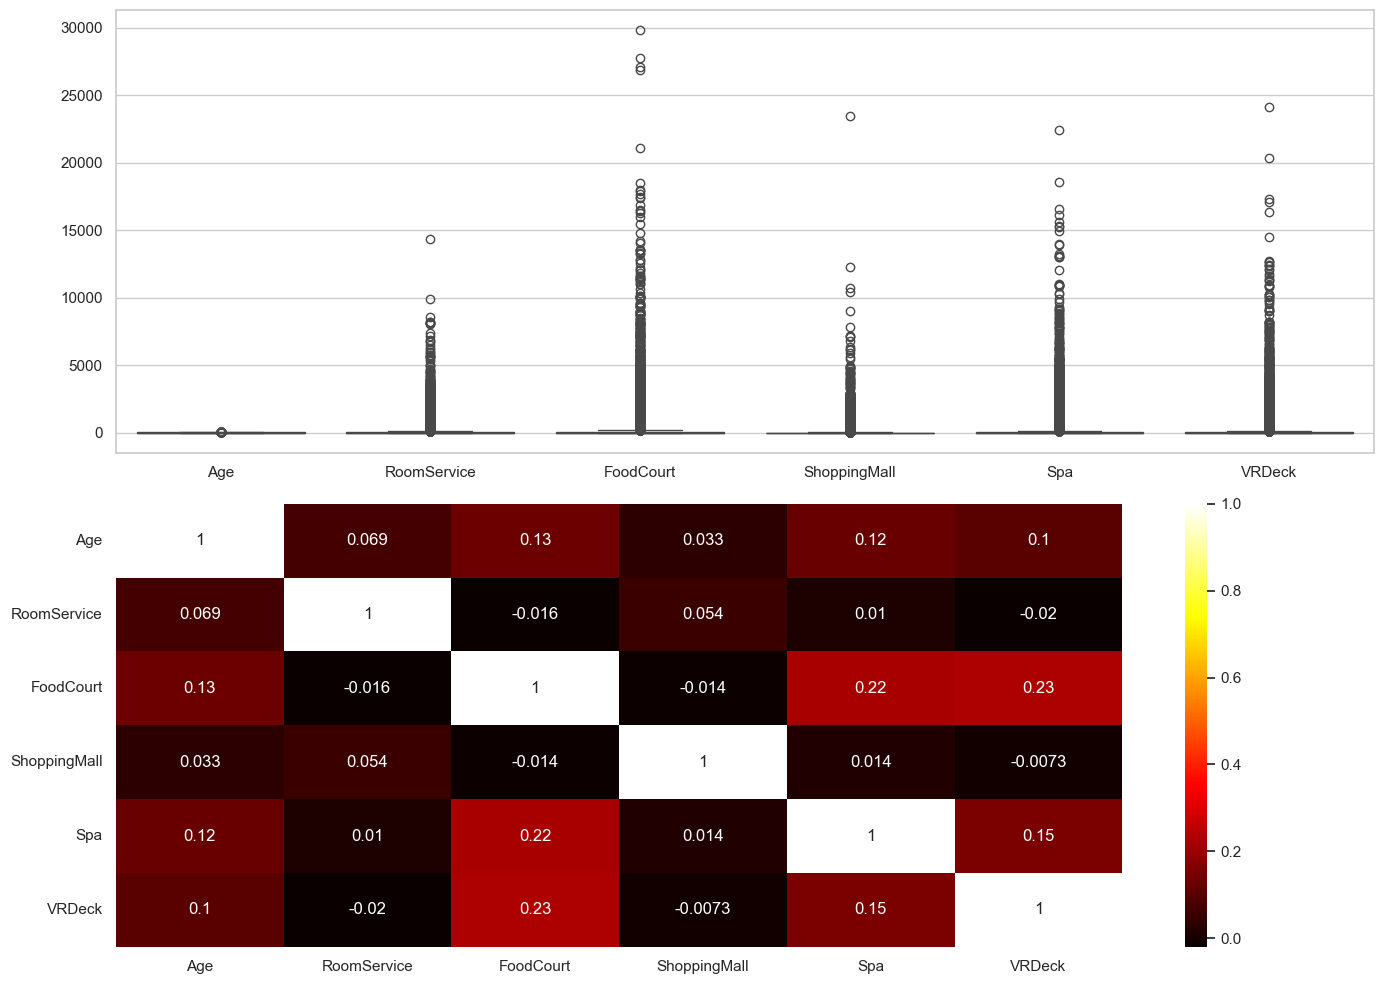

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14,10))
sns.boxplot(data=train_set.select_dtypes('number'), ax=axes[0])
sns.heatmap(data=train_set.select_dtypes('number').corr(), ax=axes[1], cmap='hot', annot=True)
plt.tight_layout()
plt.show()

Tóm lại:
- Kiểu dữ liệu: 
    - Biến `bool`: `Transported`
    - Biến số: `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`
    - Còn lại là biến phân loại.
- Tỷ lệ missing value của mỗi biến chỉ khoảng 2-2.5%.
- Trừ biến `Age`, các biến số còn lại đều có rất nhiều outliers. 
- Các biến số đều có mối tương quan không mạnh. 

## Preprocessing

- Tách `Cabin` thành `Cabin_deck`, `Cabin_number` và `Cabin_side`
- Tính `TotalSpend` của mỗi khách hàng
- Bỏ cột `Name`, `PassengerId`, `Cabin` và `Group`
- Các Missing Values được điền bằng:
    - Median đối với biến số
    - Mode đối với biến phân loại

In [8]:
def add_engineered_features(df):
    df = df.copy()
    df['TotalSpend'] = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
    cabin_split = df['Cabin'].fillna('NA/NA/NA').str.split('/', expand=True)
    df['Cabin_deck'] = cabin_split[0].replace('NA', np.nan)
    df['Cabin_number'] = pd.to_numeric(cabin_split[1].replace('NA', np.nan), errors='coerce')
    df['Cabin_side'] = cabin_split[2].replace('NA', np.nan)
    return df

raw_train = add_engineered_features(train_set.copy())
raw_test = add_engineered_features(test_set.copy())

id_col = 'PassengerId'
target_col = 'Transported'

num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'Cabin_number']
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_deck', 'Cabin_side']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
], remainder='drop')

feature_cols = num_cols + cat_cols
X = raw_train[feature_cols]
y = raw_train[target_col].astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42, test_size=0.15, stratify=y)
X_test = raw_test[feature_cols]

preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

## Models, Fit, Predict

### Models
- Bagging
- Random Forest
- AdaBoost
- GradientBoosting
- XGBoost
- Voting
- Stacking

In [ ]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    bootstrap=True,
    n_jobs=-1,
    random_state=0
)
ada = AdaBoostClassifier (
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=0
)
gbrt = GradientBoostingClassifier (
    n_estimators=100, learning_rate=0.2,
    max_depth=3, random_state=0
)
xgb_clf = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.2, max_depth=3,
    random_state=0, eval_metric='logloss'
)
# Base-learner (level 0)
clf_lr = LogisticRegression(max_iter=1000, random_state=0)
clf_rf = RandomForestClassifier(n_estimators=100, random_state=0)
clf_svc = SVC(probability=True, random_state=0)
clf_dt = DecisionTreeClassifier(max_depth=5, random_state=0)
# Meta-learner (level 1)
meta_lr = LogisticRegression(max_iter=1000, random_state=0)
# Create StackingClassifier
voting_clf = VotingClassifier(
    estimators=[('lr', clf_lr), ('dt', clf_dt), ('svc', clf_svc)],
    voting='soft'
)
stack_clf = StackingClassifier(
    estimators=[('lr', clf_lr), ('rf', clf_rf), ('svc', clf_svc)],
    final_estimator=meta_lr
)

### Fit & Predict

In [10]:
bag_model = bagging.fit(X_train_t, y_train)
bag_pred = bag_model.predict(X_val_t)

In [11]:
random_model = clf_rf.fit(X_train_t, y_train)
random_pred = random_model.predict(X_val_t)

In [12]:
ada_model = ada.fit(X_train_t, y_train)
ada_pred = ada_model.predict(X_val_t)

In [13]:
gbrt_model = gbrt.fit(X_train_t, y_train)
gbrt_pred = gbrt_model.predict(X_val_t)

In [14]:
xgb_model = xgb_clf.fit(X_train_t, y_train)
xgb_pred = xgb_model.predict(X_val_t)

In [15]:
voting_model = voting_clf.fit(X_train_t, y_train)
voting_pred = voting_model.predict(X_val_t)

In [16]:
stack_model = stack_clf.fit(X_train_t, y_train)
stack_pred = stack_model.predict(X_val_t)

## Benchmark


In [23]:
print("Benchmark:")
print(f'- Bagging | Accuracy: {np.round(accuracy_score(y_val, bag_pred), 4)} | Precision: {np.round(precision_score(y_val, bag_pred), 4)} | Recall: {np.round(recall_score(y_val, bag_pred), 4)} | F1: {np.round(f1_score(y_val, bag_pred), 4)}')
print(f'- Random Forest | Accuracy: {np.round(accuracy_score(y_val, random_pred), 4)} | Precision: {np.round(precision_score(y_val, random_pred), 4)} | Recall: {np.round(recall_score(y_val, random_pred), 4)} | F1: {np.round(f1_score(y_val, random_pred), 4)}')
print(f'- AdaBoost | Accuracy: {np.round(accuracy_score(y_val, ada_pred), 4)} | Precision: {np.round(precision_score(y_val, ada_pred), 4)} | Recall: {np.round(recall_score(y_val, ada_pred), 4)} | F1: {np.round(f1_score(y_val, ada_pred), 4)}')
print(f'- GradientBoosting | Accuracy: {np.round(accuracy_score(y_val, gbrt_pred), 4)} | Precision: {np.round(precision_score(y_val, gbrt_pred), 4)} | Recall: {np.round(recall_score(y_val, gbrt_pred), 4)} | F1: {np.round(f1_score(y_val, gbrt_pred), 4)}')
print(f'- XGBoost | Accuracy: {np.round(accuracy_score(y_val, xgb_pred), 4)} | Precision: {np.round(precision_score(y_val, xgb_pred), 4)} | Recall: {np.round(recall_score(y_val, xgb_pred), 4)} | F1: {np.round(f1_score(y_val, xgb_pred), 4)}')
print(f'- Voting | Accuracy: {np.round(accuracy_score(y_val, voting_pred), 4)} | Precision: {np.round(precision_score(y_val, voting_pred), 4)} | Recall: {np.round(recall_score(y_val, voting_pred), 4)} | F1: {np.round(f1_score(y_val, voting_pred), 4)}')
print(f'- Stacking | Accuracy: {np.round(accuracy_score(y_val, stack_pred), 4)} | Precision: {np.round(precision_score(y_val, stack_pred), 4)} | Recall: {np.round(recall_score(y_val, stack_pred), 4)} | F1: {np.round(f1_score(y_val, stack_pred), 4)}')


Benchmark:
- Bagging | Accuracy: 0.8067 | Precision: 0.8189 | Recall: 0.7915 | F1: 0.805
- Random Forest | Accuracy: 0.8083 | Precision: 0.8375 | Recall: 0.7686 | F1: 0.8016
- AdaBoost | Accuracy: 0.7646 | Precision: 0.785 | Recall: 0.7336 | F1: 0.7585
- GradientBoosting | Accuracy: 0.7952 | Precision: 0.7818 | Recall: 0.8234 | F1: 0.8021
- XGBoost | Accuracy: 0.7975 | Precision: 0.7869 | Recall: 0.8204 | F1: 0.8033
- Voting | Accuracy: 0.7929 | Precision: 0.7936 | Recall: 0.796 | F1: 0.7948
- Stacking | Accuracy: 0.8029 | Precision: 0.8086 | Recall: 0.7976 | F1: 0.8031


Tôi ưu tiên metric Recall hơn. Vì vậy, final metric của tôi là GradientBoosting

## Submission
- Dự đoán trên `test.csv`.
- Đưa kết quả vào file `submission.csv`

In [26]:
# 8) Submission scaffold
test_pred = gbrt_model.predict(X_test_t)

submission = pd.DataFrame({
    'PassengerId': test_set['PassengerId'],
    'Transported': test_pred.astype(bool)
})
submission.to_csv('submission.csv', index=False)
print('Submission saved to submission.csv')

Submission saved to submission.csv


# Kết quả
Tỉ lệ đúng là 0.80336